# Model 3 — Food ID Fine-tuning

Fine-tunes `nateraw/food` (ViT-base/16, Food-101) for binary food classification: **rice** vs **lentils**.

**Strategy:**
- Replace the 101-class classification head with a 2-class linear layer
- Phase 1: frozen backbone — train head only
- Phase 2: partial unfreezing — unfreeze last 3 transformer blocks + layernorm

**Export:** `model3_food_id.pth` (state dict) + `model3_label_map.json`

# Libraries and global variables

In [1]:
import sys
import time
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image as PILImage

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode

from transformers import AutoModelForImageClassification, AutoImageProcessor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

In [2]:
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")

PyTorch : 2.10.0+cu128
CUDA    : True


## Directory layout & paths

In [3]:
PLATFORM = "kaggle" # "colab", "kaggle", "local"

if PLATFORM == "colab":
    ROOT_IN = Path("/content/project_gn_food_estimator_v1")
    ROOT_OUT = ROOT_IN
elif PLATFORM == "kaggle":
    ROOT_IN = Path("/kaggle/input/datasets/matarauj/project-gn-data/")
    ROOT_OUT = Path("/kaggle/working/")
else:
    ROOT = Path(".").resolve()

In [4]:
####################
# INPUT
####################
DATA_DIR      = ROOT_IN  / "data"
PROCESSED_DIR = DATA_DIR / "processed"   # cropped container interior images
EXPORTS_DIR   = DATA_DIR / "exports"

# Labels file
LS_MODEL3_JSON = EXPORTS_DIR / "model3_food_v1.json"

####################
# OUTPUT
####################
MODELS_DIR   = ROOT_OUT / "models"
TRAINING_DIR = ROOT_OUT / "training"
LOGS_DIR     = TRAINING_DIR / "logs"

MODEL3_PTH       = MODELS_DIR / "model3_food_id.pth"
MODEL3_LABEL_MAP = MODELS_DIR / "model3_label_map.json"
LOG_PATH         = LOGS_DIR   / "model3_training_log.csv"
TEST_CSV_PATH    = LOGS_DIR   / "model3_test_split.csv"

In [5]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

print(f"[Setup] Models dir  : {MODELS_DIR}")
print(f"[Setup] Logs dir    : {LOGS_DIR}")
print(f"[Setup] Annotations : {LS_MODEL3_JSON}")

[Setup] Models dir  : /kaggle/working/models
[Setup] Logs dir    : /kaggle/working/training/logs
[Setup] Annotations : /kaggle/input/datasets/matarauj/project-gn-data/data/exports/model3_food_v1.json


## Parameters

In [6]:
# ── Dataset ──────────────────────────────────────────────────────────────────
MODEL3_CLASSES = ["lentils", "rice"]   # alphabetical → consistent label map
SPLIT_TRAIN    = 0.70
SPLIT_VAL      = 0.15
SPLIT_TEST     = 0.15
RANDOM_SEED    = 42

# ── Image ────────────────────────────────────────────────────────────────────
# ViT-base/16 was pre-trained at 224×224
IMAGE_SIZE = 224

In [7]:
# ── Augmentation (conservative baseline) ────────────────────────────────────
AUG_HFLIP          = True
AUG_VFLIP          = True   # valid for top-down container shots
AUG_ROTATION_DEG   = 20
AUG_COLOR_JITTER   = True
  # ColorJitter sub-parameters
AUG_BRIGHTNESS     = 0.2
AUG_CONTRAST       = 0.2
AUG_SATURATION     = 0.2
AUG_HUE            = 0.05
AUG_RCROP_SCALE    = (0.85, 1.0)  # RandomResizedCrop zoom range
AUG_ERASING_PROB   = 0.10

# ImageNet normalisation (required by the ViT feature extractor)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE = 16

# Phase 1 — frozen backbone, head only
PHASE1_EPOCHS = 10
PHASE1_LR     = 1e-3

# Phase 2 — unfreeze last 3 transformer blocks + layernorm
PHASE2_EPOCHS  = 50
PHASE2_LR_HEAD = 1e-4
PHASE2_LR_BACK = 1e-5   # lower lr for backbone layers

WEIGHT_DECAY           = 1e-2
EARLY_STOPPING_PATIENCE = 10

# Confidence threshold used at inference (mirrors config.py)
MIN_SCORE = 0.30

# HuggingFace model to use as backbone
HF_MODEL_NAME = "nateraw/food"

In [8]:
def set_seed(seed: int = RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [9]:
set_seed()

In [10]:
def check_gpu():
    """
    Report GPU availability and VRAM.
    """
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9

        print(f"[GPU] {gpu_name} - {vram_gb:.1f} GB VRAM")

        if vram_gb < 8.0:
            print(
                f"[GPU] WARNING: Less than 8 GB VRAM detected. "
                f"Consider reducing MODEL2_BATCH_SIZE (currently {MODEL2_BATCH_SIZE})."
            )
    else:
        print("[GPU] No CUDA device found - training will run on CPU.")
    return "cuda" if torch.cuda.is_available() else "cpu"

In [11]:
DEVICE = check_gpu()

[GPU] Tesla T4 - 15.6 GB VRAM


# Data loading and preprocessing

## Label Studio JSON parsing

In [12]:
def _load_ls_json(json_path: Path) -> list:
    """
    Load and minimally validate a Label Studio native JSON export.
    Returns a list of task dicts.
    """
    if not json_path.exists():
        raise FileNotFoundError(
            f"Label Studio JSON not found: {json_path}\n"
            f"Export your project using: Project → Export → JSON"
        )
    with open(json_path, "r") as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise ValueError(
            f"Expected a JSON list (Label Studio native format) "
            f"but got {type(data).__name__}. "
            f"Re-export using plain 'JSON' (not 'COCO JSON')."
        )
    if len(data) == 0:
        raise ValueError("JSON file is empty — no tasks found.")
    print(f"  Loaded {len(data)} tasks from {json_path.name}")
    return data


def _extract_label(task: dict) -> str | None:
    """
    Extract the food label from a single Label Studio task.
    Navigates: annotations[0] → result[0] → value → choices[0]
    Returns None if annotation is missing or cancelled.
    """
    annotations = task.get("annotations", [])
    if not annotations:
        return None
    ann = annotations[0]
    if ann.get("was_cancelled", False):
        return None
    result = ann.get("result", [])
    if not result:
        return None
    try:
        return result[0]["value"]["choices"][0]
    except (KeyError, IndexError):
        return None


def _split_ids(
    ids: list,
    train_ratio: float = SPLIT_TRAIN,
    val_ratio:   float = SPLIT_VAL,
    seed:        int   = RANDOM_SEED
    ) -> tuple[set, set, set]:
    rng = np.random.default_rng(seed)
    arr = np.array(ids)
    rng.shuffle(arr)
    n       = len(arr)
    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)
    train_ids = set(arr[:n_train].tolist())
    val_ids   = set(arr[n_train:n_train + n_val].tolist())
    test_ids  = set(arr[n_train + n_val:].tolist())
    print(f"  Split → train: {len(train_ids)} | val: {len(val_ids)} | test: {len(test_ids)}")
    return train_ids, val_ids, test_ids

## Build DataFrame

In [13]:
def build_dataframe(
    ls_json_path: Path = LS_MODEL3_JSON,
    image_dir:    Path = PROCESSED_DIR,
    verbose:      bool = True
    ) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Parse the Label Studio JSON and return (train_df, val_df, test_df).
    Each row has: image_path, label, label_idx, split.
    """
    if verbose:
        print(f"Loading annotations from: {ls_json_path}")

    tasks = _load_ls_json(ls_json_path)
    all_ids = [t["id"] for t in tasks]
    train_ids, val_ids, test_ids = _split_ids(all_ids)

    label_to_idx = {cls: i for i, cls in enumerate(MODEL3_CLASSES)}

    rows    = []
    skipped = 0
    for task in tasks:
        task_id = task["id"]
        label   = _extract_label(task)

        if label is None:
            print(f"  WARNING: task {task_id} has no valid annotation — skipping.")
            skipped += 1
            continue

        # Normalise label casing
        label = label.strip().lower()

        if label not in MODEL3_CLASSES:
            print(f"  WARNING: task {task_id} has unknown label '{label}' — skipping.")
            skipped += 1
            continue

        raw_filename = task.get("file_upload", "")
        filename     = raw_filename.split("-", 1)[-1]   # strip UUID prefix

        split = (
            "train" if task_id in train_ids else
            "val"   if task_id in val_ids   else
            "test"
        )
        rows.append({
            "image_path": str(image_dir / filename),
            "label":      label,
            "label_idx":  label_to_idx[label],
            "split":      split
        })

    if skipped:
        print(f"  Skipped {skipped} task(s) with missing/invalid annotations.")

    full_df  = pd.DataFrame(rows)
    train_df = full_df[full_df["split"] == "train"].reset_index(drop=True)
    val_df   = full_df[full_df["split"] == "val"].reset_index(drop=True)
    test_df  = full_df[full_df["split"] == "test"].reset_index(drop=True)

    if verbose:
        print(f"\n  Label distribution (train):")
        print(train_df["label"].value_counts().to_string())
        print(f"\n  Label distribution (val):")
        print(val_df["label"].value_counts().to_string())
        print(f"\n  Label distribution (test):")
        print(test_df["label"].value_counts().to_string())

    # Warn if any expected class is missing
    for cls in MODEL3_CLASSES:
        if cls not in full_df["label"].values:
            print(f"  WARNING: class '{cls}' has no images in the dataset.")

    return train_df, val_df, test_df

In [14]:
train_df, val_df, test_df = build_dataframe()

Loading annotations from: /kaggle/input/datasets/matarauj/project-gn-data/data/exports/model3_food_v1.json
  Loaded 503 tasks from model3_food_v1.json
  Split → train: 352 | val: 75 | test: 76
  Skipped 20 task(s) with missing/invalid annotations.

  Label distribution (train):
label
rice       176
lentils    164

  Label distribution (val):
label
rice       38
lentils    31

  Label distribution (test):
label
lentils    48
rice       26


In [15]:
# Save test split for reproducibility
test_df.to_csv(TEST_CSV_PATH, index=False)
print(f"\n  Test split saved → {TEST_CSV_PATH}")


  Test split saved → /kaggle/working/training/logs/model3_test_split.csv


## Transforms

In [16]:
def get_transforms():
    """
    Returns (train_transform, eval_transform).

    Train: augmentation + normalisation.
    Eval : resize + centre crop + normalisation only.
    """
    normalise = T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

    train_ops = []

    # Spatial augmentations
    train_ops.append(
        T.RandomResizedCrop(
            IMAGE_SIZE,
            scale=AUG_RCROP_SCALE,
            interpolation=InterpolationMode.BILINEAR
        )
    )
    if AUG_HFLIP:
        train_ops.append(T.RandomHorizontalFlip())
    if AUG_VFLIP:
        train_ops.append(T.RandomVerticalFlip())
    train_ops.append(T.RandomRotation(degrees=AUG_ROTATION_DEG))

    # Colour augmentations
    if AUG_COLOR_JITTER:
        train_ops.append(
            T.ColorJitter(
                brightness=AUG_BRIGHTNESS,
                contrast=AUG_CONTRAST,
                saturation=AUG_SATURATION,
                hue=AUG_HUE
            )
        )

    # ToTensor + normalise
    train_ops.append(T.ToTensor())
    train_ops.append(normalise)

    # Random erasing applied after ToTensor
    train_ops.append(T.RandomErasing(p=AUG_ERASING_PROB))

    train_transform = T.Compose(train_ops)

    eval_transform = T.Compose([
        T.Resize(IMAGE_SIZE, interpolation=InterpolationMode.BILINEAR),
        T.CenterCrop(IMAGE_SIZE),
        T.ToTensor(),
        normalise
    ])

    return train_transform, eval_transform

In [17]:
train_transform, eval_transform = get_transforms()
print("Transforms ready.")

Transforms ready.


## Dataset and DataLoaders

In [18]:
class FoodDataset(Dataset):
    """
    Minimal PyTorch Dataset for food classification.
    Loads cropped container images and returns (tensor, label_idx).
    """
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row   = self.df.iloc[idx]
        image = PILImage.open(row["image_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = int(row["label_idx"])
        return image, label


def get_dataloaders(
    train_df:        pd.DataFrame,
    val_df:          pd.DataFrame,
    test_df:         pd.DataFrame,
    train_transform,
    eval_transform,
    batch_size: int  = BATCH_SIZE
    ) -> tuple[DataLoader, DataLoader, DataLoader]:

    train_ds = FoodDataset(train_df, transform=train_transform)
    val_ds   = FoodDataset(val_df,   transform=eval_transform)
    test_ds  = FoodDataset(test_df,  transform=eval_transform)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True
    )

    print(f"DataLoaders ready.")
    print(f"  Train batches : {len(train_loader)}  ({len(train_ds)} images)")
    print(f"  Val batches   : {len(val_loader)}  ({len(val_ds)} images)")
    print(f"  Test batches  : {len(test_loader)}  ({len(test_ds)} images)")

    return train_loader, val_loader, test_loader

In [19]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_df, val_df, test_df, train_transform, eval_transform
)

DataLoaders ready.
  Train batches : 22  (340 images)
  Val batches   : 5  (69 images)
  Test batches  : 5  (74 images)


## Class weights

In [20]:
def compute_class_weights(train_df: pd.DataFrame) -> torch.Tensor:
    """
    Inverse-frequency class weights.
    With a balanced dataset these will be close to 1.0.
    weight[c] = total / (n_classes × count[c])
    """
    counts = train_df["label"].value_counts()
    ordered_counts = [counts.get(cls, 1) for cls in MODEL3_CLASSES]
    total = sum(ordered_counts)

    weights = torch.tensor(
        [total / (len(MODEL3_CLASSES) * c) for c in ordered_counts],
        dtype=torch.float32
    )
    print("Class weights:")
    for cls, w in zip(MODEL3_CLASSES, weights):
        print(f"  {cls:10s} : {w:.4f}")
    return weights

In [21]:
class_weights = compute_class_weights(train_df).to(DEVICE)

Class weights:
  lentils    : 1.0366
  rice       : 0.9659


# Model

## Load backbone and replace head

In [22]:
print(f"Loading backbone: {HF_MODEL_NAME} ...")

model = AutoModelForImageClassification.from_pretrained(
    HF_MODEL_NAME,
    ignore_mismatched_sizes=True   # suppress warning when we replace the head
)

# ── Replace the classification head ─────────────────────────────────────────
# nateraw/food uses ViT-base/16: hidden_size = 768
hidden_size = model.config.hidden_size
num_new_classes = len(MODEL3_CLASSES)

model.classifier = nn.Linear(hidden_size, num_new_classes)

# Update the config so id2label / label2id reflect our classes
model.config.num_labels = num_new_classes
model.config.id2label = {i: cls for i, cls in enumerate(MODEL3_CLASSES)}
model.config.label2id = {cls: i for i, cls in enumerate(MODEL3_CLASSES)}

model = model.to(DEVICE)

print(f"Backbone loaded. Hidden size: {hidden_size}")
print(f"New head: Linear({hidden_size}, {num_new_classes})")
print(f"Classes : {MODEL3_CLASSES}")

Loading backbone: nateraw/food ...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/344M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Backbone loaded. Hidden size: 768
New head: Linear(768, 2)
Classes : ['lentils', 'rice']


## Freeze / unfreeze helpers

In [23]:
def freeze_backbone(model: nn.Module) -> None:
    """
    Freeze all parameters except the classifier head.
    Phase 1: trains only the new 2-class linear layer.
    """
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith("classifier")

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Phase 1 — trainable params: {trainable:,} / {total:,} "
          f"({trainable/total*100:.2f}%)")


def unfreeze_top_blocks(
    model: nn.Module,
    n_blocks: int = 3
    ) -> dict[str, list]:
    """
    Unfreeze the last n_blocks transformer encoder layers,
    the final layernorm, and the classifier head.

    Returns a dict of parameter groups for the optimizer:
        {"backbone": [...], "head": [...]}
    so we can assign different learning rates.

    ViT-base/16 has 12 encoder layers (indices 0–11).
    n_blocks=3 unfreezes layers 9, 10, 11.
    """
    total_layers  = len(model.vit.encoder.layer)
    unfreeze_from = total_layers - n_blocks

    backbone_params = []
    head_params     = []

    for name, param in model.named_parameters():
        if name.startswith("classifier"):
            param.requires_grad = True
            head_params.append(param)
        elif name.startswith("vit.layernorm"):
            param.requires_grad = True
            backbone_params.append(param)
        elif name.startswith("vit.encoder.layer"):
            # Extract layer index: "vit.encoder.layer.10.attention..."
            parts = name.split(".")
            layer_idx = int(parts[3])

            if layer_idx >= unfreeze_from:
                param.requires_grad = True
                backbone_params.append(param)
            else:
                param.requires_grad = False
        else:
            param.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())

    print(f"Phase 2 — unfroze top {n_blocks} blocks (layers {unfreeze_from}-{total_layers-1}) "
          f"+ layernorm + head")
    print(f"         trainable params: {trainable:,} / {total:,} "
          f"({trainable/total*100:.2f}%)")

    return {"backbone": backbone_params, "head": head_params}

# Training loop

In [24]:
def run_epoch(
    model:       nn.Module,
    loader:      DataLoader,
    criterion:   nn.Module,
    optimizer:   torch.optim.Optimizer | None,
    device:      str,
    is_train:    bool
    ) -> tuple[float, float]:
    """
    Run one epoch of training or validation.
    Returns (mean_loss, accuracy).
    """
    model.train(is_train)
    total_loss = 0.0
    correct = 0
    total = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()

    with ctx:
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(pixel_values=images).logits
            loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total


class EarlyStopping:
    """
    Stops training when validation loss has not improved for `patience` epochs.
    """

    def __init__(self, patience: int = EARLY_STOPPING_PATIENCE, min_delta: float = 1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = float("inf")
        self.counter    = 0
        self.best_state = None

    def step(self, val_loss: float, model: nn.Module) -> bool:
        """
        Returns True if training should stop.
        """
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            # Deep-copy the state dict so we can restore the best weights
            import copy
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)
            print(f"  Restored best weights (val_loss: {self.best_loss:.4f})")

## Phase 1 - fronzen backbone

In [25]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Freeze everything except the head
freeze_backbone(model)

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR,
    weight_decay=WEIGHT_DECAY
)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=PHASE1_EPOCHS
)

early_stop_p1 = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)
log_rows = []

print(f"\n{'='*65}")
print(f"Phase 1 — frozen backbone, training head only")
print(f"{'='*65}")
print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  "
      f"{'Val Loss':>9}  {'Val Acc':>8}  {'LR':>10}")

t0 = time.time()
for epoch in range(PHASE1_EPOCHS):
    train_loss, train_acc = run_epoch(
        model, train_loader, criterion, optimizer_p1, DEVICE, is_train=True
    )
    val_loss, val_acc = run_epoch(
        model, val_loader, criterion, None, DEVICE, is_train=False
    )
    scheduler_p1.step()

    lr_now = optimizer_p1.param_groups[0]["lr"]
    print(f"  {epoch+1:4d}  {train_loss:10.4f}  {train_acc:9.4f}  "
          f"{val_loss:9.4f}  {val_acc:8.4f}  {lr_now:10.2e}")

    log_rows.append({
        "phase": 1, "epoch": epoch + 1,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss,   "val_acc": val_acc
    })

    if early_stop_p1.step(val_loss, model):
        print(f"  Early stopping at epoch {epoch + 1}.")
        break

early_stop_p1.restore_best(model)
print(f"\n  Phase 1 complete — {time.time() - t0:.0f}s")

Phase 1 — trainable params: 1,538 / 85,800,194 (0.00%)

Phase 1 — frozen backbone, training head only
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc          LR
     1      0.4723     0.8588     0.2074    1.0000    9.76e-04
     2      0.1996     0.9794     0.0921    1.0000    9.05e-04
     3      0.1283     0.9853     0.0611    1.0000    7.94e-04
     4      0.0942     0.9882     0.0466    1.0000    6.55e-04
     5      0.0743     0.9941     0.0403    1.0000    5.00e-04
     6      0.0622     0.9971     0.0370    1.0000    3.45e-04
     7      0.0650     0.9912     0.0340    1.0000    2.06e-04
     8      0.0594     0.9941     0.0330    1.0000    9.55e-05
     9      0.0523     0.9941     0.0324    1.0000    2.45e-05
    10      0.0481     1.0000     0.0324    1.0000    0.00e+00
  Restored best weights (val_loss: 0.0324)

  Phase 1 complete — 81s


## Phase 2 - partial unfreezing

In [26]:
param_groups = unfreeze_top_blocks(model, n_blocks=3)

# Discriminative learning rates: lower for backbone, higher for head
optimizer_p2 = torch.optim.AdamW(
    [
        {"params": param_groups["backbone"], "lr": PHASE2_LR_BACK},
        {"params": param_groups["head"], "lr": PHASE2_LR_HEAD}
    ],
    weight_decay=WEIGHT_DECAY
)
scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=PHASE2_EPOCHS
)

early_stop_p2 = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)

print(f"\n{'='*65}")
print(f"Phase 2 — partial unfreezing (top 3 blocks)")
print(f"  Backbone LR : {PHASE2_LR_BACK:.1e}  |  Head LR : {PHASE2_LR_HEAD:.1e}")
print(f"{'='*65}")
print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  "
      f"{'Val Loss':>9}  {'Val Acc':>8}")

t0 = time.time()
for epoch in range(PHASE2_EPOCHS):
    train_loss, train_acc = run_epoch(
        model, train_loader, criterion, optimizer_p2, DEVICE, is_train=True
    )
    val_loss, val_acc = run_epoch(
        model, val_loader, criterion, None, DEVICE, is_train=False
    )
    scheduler_p2.step()

    print(f"  {epoch+1:4d}  {train_loss:10.4f}  {train_acc:9.4f}  "
          f"{val_loss:9.4f}  {val_acc:8.4f}")

    log_rows.append({
        "phase": 2, "epoch": epoch + 1,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss,   "val_acc": val_acc
    })

    if early_stop_p2.step(val_loss, model):
        print(f"  Early stopping at epoch {epoch + 1}.")
        break

early_stop_p2.restore_best(model)
print(f"\n  Phase 2 complete — {time.time() - t0:.0f}s")

Phase 2 — unfroze top 3 blocks (layers 9-11) + layernorm + head
         trainable params: 21,266,690 / 85,800,194 (24.79%)

Phase 2 — partial unfreezing (top 3 blocks)
  Backbone LR : 1.0e-05  |  Head LR : 1.0e-04
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc
     1      0.0431     1.0000     0.0200    1.0000
     2      0.0222     1.0000     0.0144    1.0000
     3      0.0181     1.0000     0.0113    1.0000
     4      0.0177     0.9971     0.0075    1.0000
     5      0.0095     1.0000     0.0062    1.0000
     6      0.0097     1.0000     0.0054    1.0000
     7      0.0063     1.0000     0.0047    1.0000
     8      0.0040     1.0000     0.0041    1.0000
     9      0.0046     1.0000     0.0034    1.0000
    10      0.0044     1.0000     0.0034    1.0000
    11      0.0036     1.0000     0.0026    1.0000
    12      0.0036     1.0000     0.0020    1.0000
    13      0.0047     0.9971     0.0018    1.0000
    14      0.0023     1.0000     0.0016    1.0000
    15      0.0024  

## Save training log

In [27]:
log_df = pd.DataFrame(log_rows)
log_df.to_csv(LOG_PATH, index=False)
print(f"Training log saved → {LOG_PATH}")

Training log saved → /kaggle/working/training/logs/model3_training_log.csv


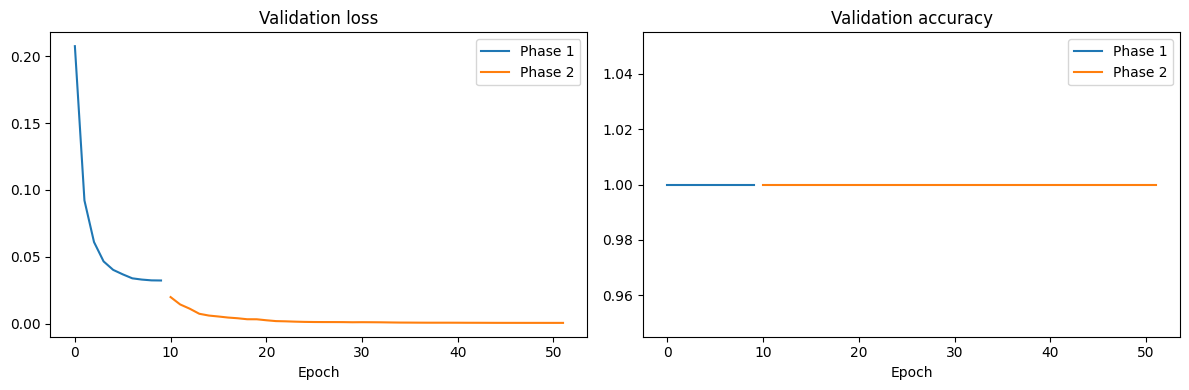

In [28]:
# Quick learning curve plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for phase, group in log_df.groupby("phase"):
    label = f"Phase {phase}"
    axes[0].plot(group["val_loss"],  label=label)
    axes[1].plot(group["val_acc"],   label=label)

axes[0].set_title("Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

# Export model

In [29]:
# Save state dict
torch.save(model.state_dict(), MODEL3_PTH)
print(f"[Done] State dict → {MODEL3_PTH}")

# Save label map — critical for correct index→class mapping at inference
label_map = {cls: i for i, cls in enumerate(MODEL3_CLASSES)}
with open(MODEL3_LABEL_MAP, "w") as f:
    json.dump(label_map, f, indent=2)

print(f"[Done] Label map  → {MODEL3_LABEL_MAP}")
print(f"       Contents   : {label_map}")

[Done] State dict → /kaggle/working/models/model3_food_id.pth
[Done] Label map  → /kaggle/working/models/model3_label_map.json
       Contents   : {'lentils': 0, 'rice': 1}


# Evaluation

## Collect predictions on the test set

In [30]:
model.eval()

all_labels      = []
all_preds       = []
all_confidences = []   # max softmax probability
all_probs       = []   # full softmax distribution

softmax = nn.Softmax(dim=1)

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        outputs = model(pixel_values=images).logits
        probs   = softmax(outputs).cpu()

        preds       = probs.argmax(dim=1).numpy()
        confidences = probs.max(dim=1).values.numpy()

        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_confidences.extend(confidences)
        all_probs.extend(probs.numpy())

all_labels      = np.array(all_labels)
all_preds       = np.array(all_preds)
all_confidences = np.array(all_confidences)
all_probs       = np.array(all_probs)

print(f"Test set: {len(all_labels)} images")

Test set: 74 images


## Classification metrics

In [31]:
acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
rec  = recall_score(all_labels, all_preds,    average="macro", zero_division=0)
f1   = f1_score(all_labels, all_preds,        average="macro", zero_division=0)

print("\n── Test set metrics ─────────────────────────")
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  Precision : {prec:.4f}  (macro)")
print(f"  Recall    : {rec:.4f}  (macro)")
print(f"  F1 score  : {f1:.4f}  (macro)")

# Per-class report
print("\n── Per-class breakdown ──────────────────────")
for i, cls in enumerate(MODEL3_CLASSES):
    mask      = all_labels == i
    cls_acc   = (all_preds[mask] == i).mean() if mask.sum() > 0 else 0.0
    cls_prec  = precision_score(all_labels == i, all_preds == i, zero_division=0)
    cls_rec   = recall_score(all_labels == i,    all_preds == i, zero_division=0)
    cls_f1    = f1_score(all_labels == i,         all_preds == i, zero_division=0)
    n         = mask.sum()
    print(f"  {cls:10s}  n={n:3d}  acc={cls_acc:.3f}  "
          f"prec={cls_prec:.3f}  rec={cls_rec:.3f}  f1={cls_f1:.3f}")


── Test set metrics ─────────────────────────
  Accuracy  : 1.0000  (100.0%)
  Precision : 1.0000  (macro)
  Recall    : 1.0000  (macro)
  F1 score  : 1.0000  (macro)

── Per-class breakdown ──────────────────────
  lentils     n= 48  acc=1.000  prec=1.000  rec=1.000  f1=1.000
  rice        n= 26  acc=1.000  prec=1.000  rec=1.000  f1=1.000


## Confusion matrix

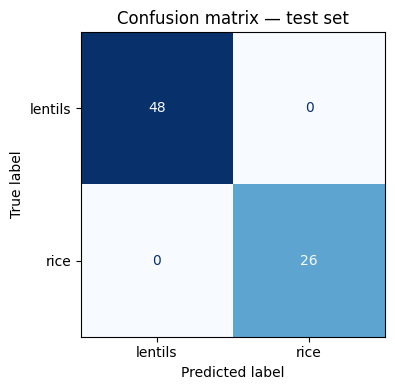

In [32]:
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=MODEL3_CLASSES)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion matrix — test set")
plt.tight_layout()
plt.show()

## Confidence distribution

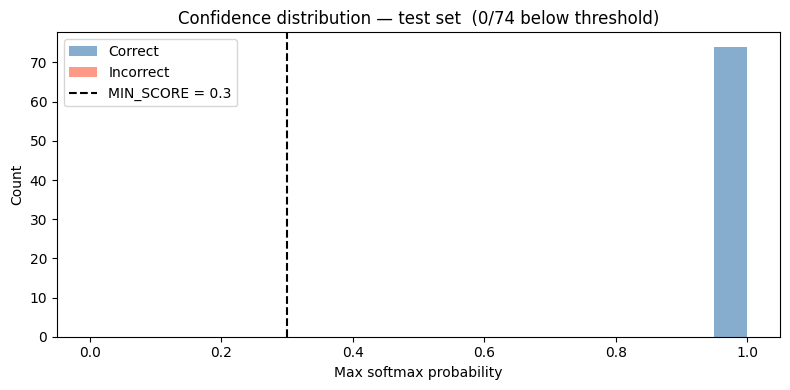


Images below MIN_SCORE (0.3): 0/74 (0.0%)
These would trigger the manual override UI in the app.


In [33]:
fig, ax = plt.subplots(figsize=(8, 4))

# Separate correct and incorrect predictions
correct_mask   = all_preds == all_labels
incorrect_mask = ~correct_mask

ax.hist(
    all_confidences[correct_mask],
    bins=20, range=(0, 1), alpha=0.65,
    color="steelblue", label="Correct"
)
ax.hist(
    all_confidences[incorrect_mask],
    bins=20, range=(0, 1), alpha=0.65,
    color="tomato", label="Incorrect"
)
ax.axvline(MIN_SCORE, color="black", linestyle="--", linewidth=1.5,
           label=f"MIN_SCORE = {MIN_SCORE}")

below = (all_confidences < MIN_SCORE).sum()
ax.set_title(
    f"Confidence distribution — test set  "
    f"({below}/{len(all_confidences)} below threshold)"
)
ax.set_xlabel("Max softmax probability")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nImages below MIN_SCORE ({MIN_SCORE}): "
      f"{below}/{len(all_confidences)} "
      f"({below/len(all_confidences)*100:.1f}%)")
print("These would trigger the manual override UI in the app.")

# Visual preview

Grid of test images showing the crop, true label, predicted label, and confidence.
Correct predictions have a **green** border; incorrect have a **red** border.
Images below `MIN_SCORE` are marked with ⚠.

In [34]:
def show_prediction_grid(
    df:           pd.DataFrame,
    labels_true:  np.ndarray,
    labels_pred:  np.ndarray,
    confidences:  np.ndarray,
    label_names:  list[str],
    n_show:       int  = 24,
    n_cols:       int  = 6,
    seed:         int  = RANDOM_SEED
    ) -> None:
    """
    Display a random sample of test images with prediction annotations.
    """
    rng     = np.random.default_rng(seed)
    indices = rng.choice(len(df), size=min(n_show, len(df)), replace=False)
    indices = sorted(indices)

    n_rows = int(np.ceil(len(indices) / n_cols))
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 2.5, n_rows * 3.0)
    )
    axes = axes.flatten()

    for ax_idx, img_idx in enumerate(indices):
        ax     = axes[ax_idx]
        row    = df.iloc[img_idx]
        image  = PILImage.open(row["image_path"]).convert("RGB")
        image  = image.resize((IMAGE_SIZE, IMAGE_SIZE))

        true_name = label_names[labels_true[img_idx]]
        pred_name = label_names[labels_pred[img_idx]]
        conf      = confidences[img_idx]
        correct   = labels_true[img_idx] == labels_pred[img_idx]
        low_conf  = conf < MIN_SCORE

        ax.imshow(image)
        ax.axis("off")

        # Coloured border
        border_colour = "#2ecc71" if correct else "#e74c3c"
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(border_colour)
            spine.set_linewidth(3)

        warn  = " ⚠" if low_conf else ""
        title = f"T: {true_name}\nP: {pred_name}  {conf:.0%}{warn}"
        title_colour = "green" if correct else "red"
        ax.set_title(title, fontsize=7, color=title_colour, pad=2)

    # Hide unused axes
    for ax in axes[len(indices):]:
        ax.set_visible(False)

    # Legend
    green_patch = mpatches.Patch(color="#2ecc71", label="Correct")
    red_patch   = mpatches.Patch(color="#e74c3c", label="Incorrect")
    fig.legend(
        handles=[green_patch, red_patch],
        loc="lower center",
        ncol=2,
        fontsize=9,
        frameon=False
    )

    fig.suptitle(
        f"Test set predictions  (T = true label, P = predicted, ⚠ = below MIN_SCORE)",
        fontsize=10
    )
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

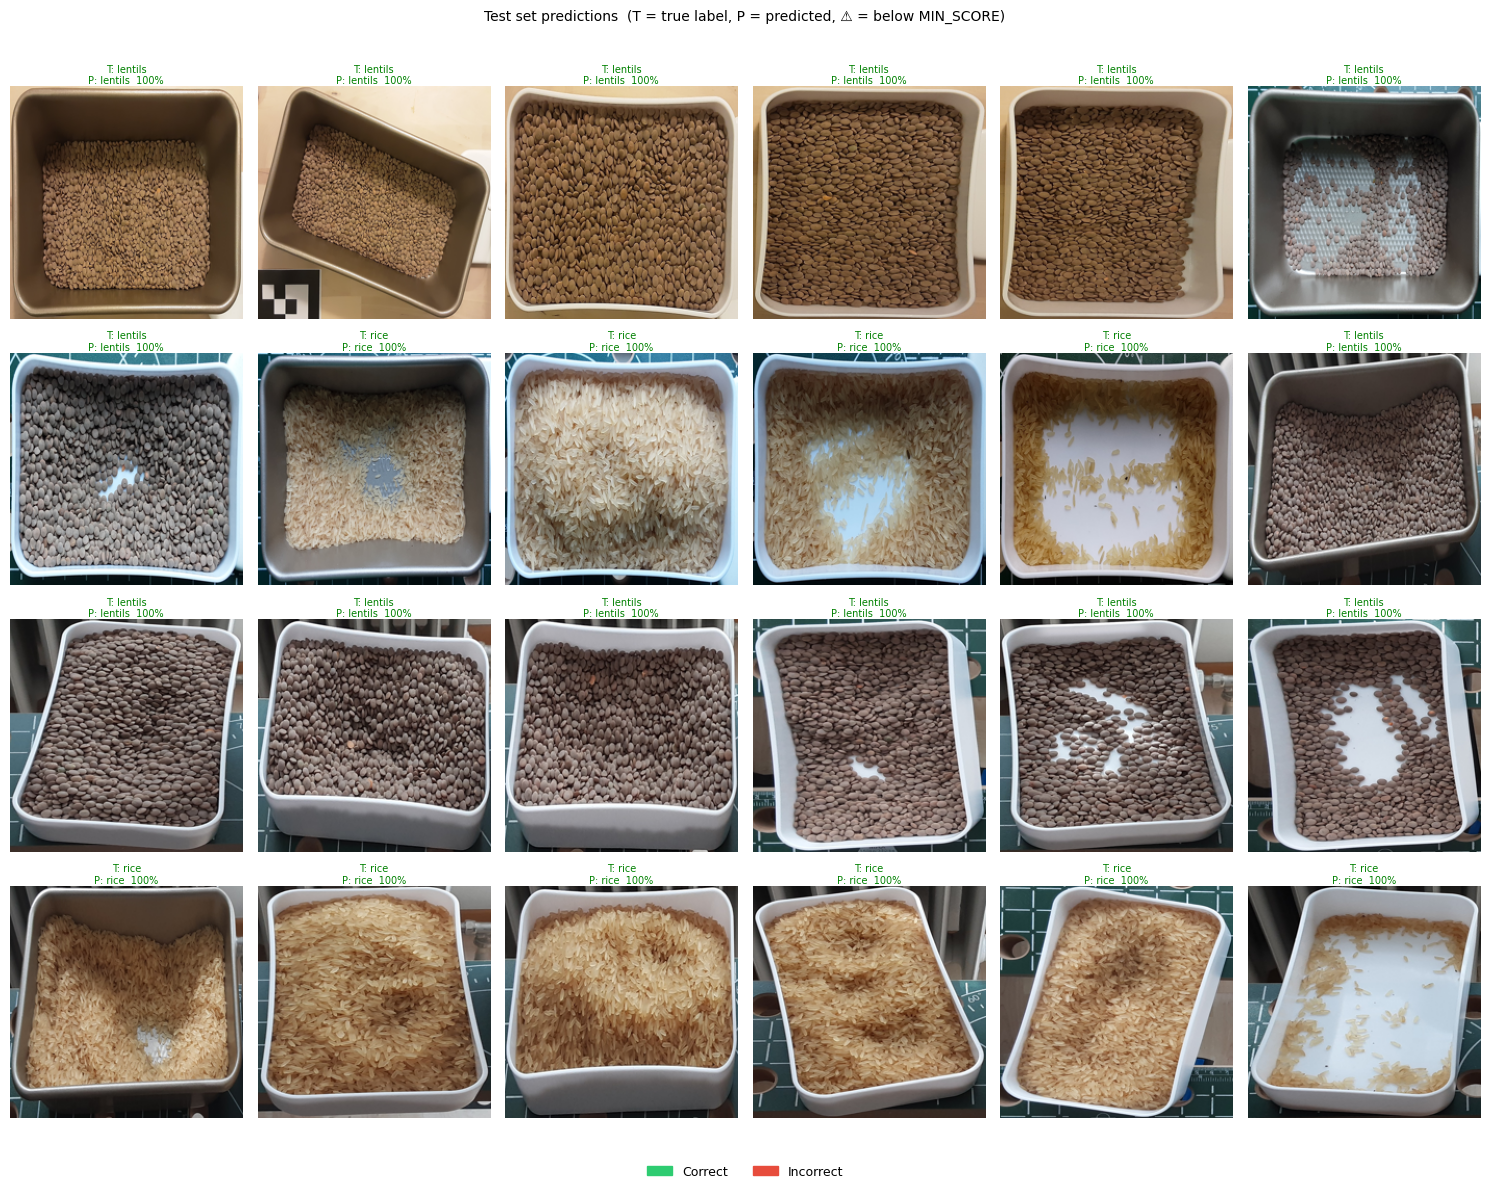

In [35]:
show_prediction_grid(
    df           = test_df,
    labels_true  = all_labels,
    labels_pred  = all_preds,
    confidences  = all_confidences,
    label_names  = MODEL3_CLASSES
)

## Incorrect predictions only

In [36]:
# Build a sub-dataframe containing only the incorrectly predicted test images
error_mask   = all_preds != all_labels
n_errors     = error_mask.sum()
print(f"Incorrect predictions: {n_errors} / {len(all_labels)}")

if n_errors > 0:
    error_df = test_df[error_mask].reset_index(drop=True)
    show_prediction_grid(
        df           = error_df,
        labels_true  = all_labels[error_mask],
        labels_pred  = all_preds[error_mask],
        confidences  = all_confidences[error_mask],
        label_names  = MODEL3_CLASSES,
        n_show       = min(n_errors, 24),
        seed         = RANDOM_SEED
    )
else:
    print("No errors to display — perfect test set accuracy.")

Incorrect predictions: 0 / 74
No errors to display — perfect test set accuracy.


# Quick inference check

In [37]:
# Reload model from saved state dict and run a single inference to verify
# that the export round-trip works correctly before copying to the app.

print("Verifying export round-trip...")

# Load label map
with open(MODEL3_LABEL_MAP) as f:
    loaded_label_map = json.load(f)
idx_to_label = {v: k for k, v in loaded_label_map.items()}
print(f"  Label map loaded: {loaded_label_map}")

# Rebuild model architecture
verify_model = AutoModelForImageClassification.from_pretrained(
    HF_MODEL_NAME,
    ignore_mismatched_sizes=True
)
verify_model.classifier = nn.Linear(
    verify_model.config.hidden_size, len(loaded_label_map)
)
verify_model.load_state_dict(torch.load(MODEL3_PTH, map_location="cpu"))
verify_model.eval()

# Pick one test image
sample_row    = test_df.iloc[0]
sample_image  = PILImage.open(sample_row["image_path"]).convert("RGB")
sample_tensor = eval_transform(sample_image).unsqueeze(0)

with torch.no_grad():
    logits = verify_model(pixel_values=sample_tensor).logits
    probs  = nn.Softmax(dim=1)(logits)[0]

pred_idx  = probs.argmax().item()
pred_label = idx_to_label[pred_idx]
confidence = probs[pred_idx].item()
true_label = sample_row["label"]

print(f"  Sample image  : {sample_row['image_path']}")
print(f"  True label    : {true_label}")
print(f"  Predicted     : {pred_label}  (confidence: {confidence:.3f})")
for i, cls in enumerate(MODEL3_CLASSES):
    print(f"    {cls:10s} : {probs[i].item():.4f}")

print("\nExport round-trip OK — model is ready to copy to models/model3_food_id.pth")

Verifying export round-trip...
  Label map loaded: {'lentils': 0, 'rice': 1}


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

  Sample image  : /kaggle/input/datasets/matarauj/project-gn-data/data/processed/20260316_212943.jpg
  True label    : lentils
  Predicted     : lentils  (confidence: 1.000)
    lentils    : 0.9999
    rice       : 0.0001

Export round-trip OK — model is ready to copy to models/model3_food_id.pth
